# ECB Policy Rates and Euro-Area Bank Profitability

**Research question:** How did the ECB deposit facility rate cycle coincide with aggregate net interest margin (NIM) and return on equity (ROE) for significant euro-area institutions?

This is a **descriptive event study**, not a causal regression. It uses selected official ECB quarter-end anchors and explicitly recognizes sample-composition changes and other profitability drivers.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
DATA = BASE / 'data'
CHARTS = BASE / 'charts'
CHARTS.mkdir(exist_ok=True)

anchors = pd.read_csv(DATA / 'ecb_profitability_anchors.csv')
events = pd.read_csv(DATA / 'ecb_rate_events.csv', parse_dates=['EffectiveDate'])
anchors

,Period,DFR,NIM,ROE,Phase
0,Q4 2021,-0.005,0.0121,0.0672,Pre-hiking
1,Q4 2022,0.020,0.0136,0.0768,Tightening
2,Q4 2023,0.040,0.0160,0.0931,Peak
3,Q4 2024,0.030,0.0160,0.0954,Early easing
4,Q4 2025,0.020,0.0152,0.0953,Easing / hold
5,Q1 2026,0.020,0.0154,0.1002,Hold


## 1. Map the policy cycle

The deposit facility rate is used because it is the ECB's policy steering rate in the current operating framework. The rate-decision table is sourced from the ECB's official key-interest-rates page.

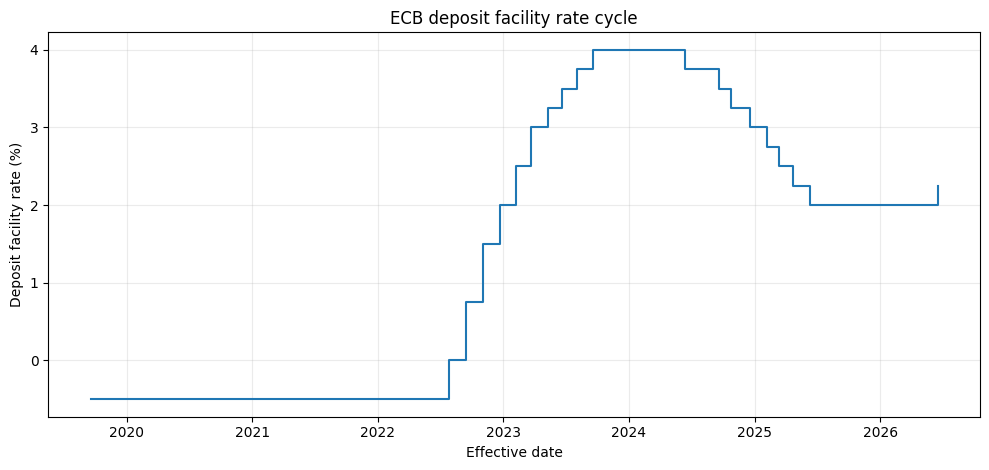

In [2]:
events['Change_bp'] = events['DFR'].diff()*10000
fig, ax = plt.subplots(figsize=(10,4.8))
ax.step(events['EffectiveDate'], events['DFR']*100, where='post')
ax.set_title('ECB deposit facility rate cycle')
ax.set_ylabel('Deposit facility rate (%)')
ax.set_xlabel('Effective date')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(CHARTS / 'ecb_deposit_rate_cycle.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. Compare profitability anchors

The small sample is useful for visualizing phases of the cycle, but not for precise inference. The NIM and ROE series also reflect changes in the supervised sample, mergers, reclassifications, provisioning, fee income, costs and capital.

In [3]:
display_df = anchors.copy()
for col in ['DFR','NIM','ROE']:
    display_df[col] = display_df[col]*100
display_df

,Period,DFR,NIM,ROE,Phase
0,Q4 2021,-0.5,1.21,6.72,Pre-hiking
1,Q4 2022,2.0,1.36,7.68,Tightening
2,Q4 2023,4.0,1.60,9.31,Peak
3,Q4 2024,3.0,1.60,9.54,Early easing
4,Q4 2025,2.0,1.52,9.53,Easing / hold
5,Q1 2026,2.0,1.54,10.02,Hold


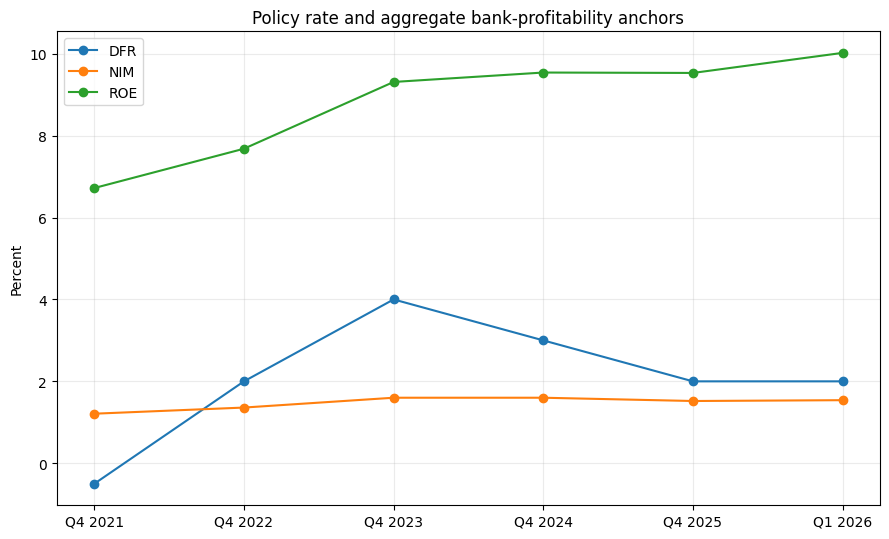

In [4]:
fig, ax = plt.subplots(figsize=(9,5.5))
x = np.arange(len(anchors))
ax.plot(x, anchors['DFR']*100, marker='o', label='DFR')
ax.plot(x, anchors['NIM']*100, marker='o', label='NIM')
ax.plot(x, anchors['ROE']*100, marker='o', label='ROE')
ax.set_xticks(x, anchors['Period'])
ax.set_ylabel('Percent')
ax.set_title('Policy rate and aggregate bank-profitability anchors')
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(CHARTS / 'ecb_rates_nim_roe.png', dpi=200, bbox_inches='tight')
plt.show()

In [5]:
corr_dfr_nim = anchors['DFR'].corr(anchors['NIM'])
corr_dfr_roe = anchors['DFR'].corr(anchors['ROE'])
print(f'Descriptive correlation: DFR vs NIM = {corr_dfr_nim:.2f}')
print(f'Descriptive correlation: DFR vs ROE = {corr_dfr_roe:.2f}')
print(f'NIM change Q4 2021 to Q4 2023 = {(anchors.loc[2,"NIM"]-anchors.loc[0,"NIM"])*10000:.0f} bp')
print(f'ROE change Q4 2021 to Q4 2023 = {(anchors.loc[2,"ROE"]-anchors.loc[0,"ROE"])*100:.2f} percentage points')

Descriptive correlation: DFR vs NIM = 0.89
Descriptive correlation: DFR vs ROE = 0.72
NIM change Q4 2021 to Q4 2023 = 39 bp
ROE change Q4 2021 to Q4 2023 = 2.59 percentage points


## 3. Transparent sensitivity framework

Illustrative assumptions:

- 100bp DFR move -> 6bp NIM move
- Assets/equity = 12x
- Cash tax rate = 25%

The simplified ROE impact is: **NIM change x assets/equity x (1 - tax rate)**. This is a scenario tool, not a forecast.

In [6]:
base_dfr = 0.0200
base_nim = 0.0152
base_roe = 0.0953
nim_per_100bp = 0.0006
assets_to_equity = 12.0
tax_rate = 0.25
shocks_bp = np.array([-100,-50,0,50,100])

scenario = pd.DataFrame({'DFR_Shock_bp':shocks_bp})
scenario['Scenario_DFR'] = base_dfr + scenario['DFR_Shock_bp']/10000
scenario['NIM_Change'] = scenario['DFR_Shock_bp']/100 * nim_per_100bp
scenario['Scenario_NIM'] = base_nim + scenario['NIM_Change']
scenario['ROE_Impact'] = scenario['NIM_Change']*assets_to_equity*(1-tax_rate)
scenario['Scenario_ROE'] = base_roe + scenario['ROE_Impact']
scenario.style.format({c:'{:.2%}' for c in scenario.columns[1:]})

,DFR_Shock_bp,Scenario_DFR,NIM_Change,Scenario_NIM,ROE_Impact,Scenario_ROE
0,-100,1.00%,-0.06%,1.46%,-0.54%,8.99%
1,-50,1.50%,-0.03%,1.49%,-0.27%,9.26%
2,0,2.00%,0.00%,1.52%,0.00%,9.53%
3,50,2.50%,0.03%,1.55%,0.27%,9.80%
4,100,3.00%,0.06%,1.58%,0.54%,10.07%


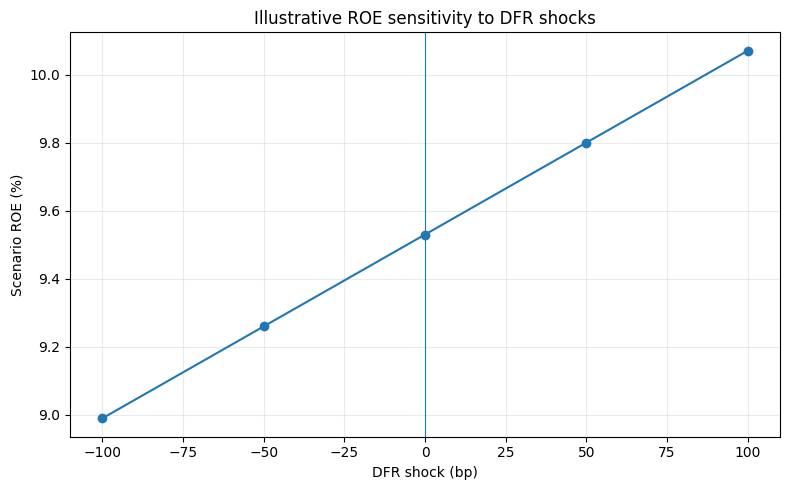

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(scenario['DFR_Shock_bp'], scenario['Scenario_ROE']*100, marker='o')
ax.axvline(0, linewidth=0.8)
ax.set_title('Illustrative ROE sensitivity to DFR shocks')
ax.set_xlabel('DFR shock (bp)')
ax.set_ylabel('Scenario ROE (%)')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(CHARTS / 'ecb_roe_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

## Interview-ready conclusion

1. NIM rose from **1.21% in Q4 2021** to **1.60% in Q4 2023**, while the DFR moved from **-0.50% to 4.00%**.
2. ROE rose from **6.72% to 9.31%** over the same anchor period.
3. By Q4 2025, NIM had eased to **1.52%** while ROE remained **9.53%**. That is evidence that profitability cannot be reduced to policy rates alone.

The defensible wording is: **“The tightening cycle coincided with aggregate margin and ROE expansion.”** It is not: **“Higher rates caused the entire improvement.”**

A next-stage analysis would use bank-level panel data, deposit betas, asset/liability repricing gaps, loan mix, hedges, fees, cost-to-income, provisions and capital distributions.